In [1]:
# Cell 1 — Imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
# Cell 2 — Load and explore data
df = pd.read_csv('Salary_dataset.csv')
print(df.head(10))
print(f"\nShape: {df.shape}")
print(f"\nMissing values:\n{df.isnull().sum()}")
print(f"\nBasic stats:\n{df.describe()}")

   YearsExperience  Salary
0              1.1   39343
1              1.3   46205
2              1.5   37731
3              2.0   43525
4              2.2   39891
5              2.9   56642
6              3.0   60150
7              3.2   54445
8              3.2   64445
9              3.7   57189

Shape: (35, 2)

Missing values:
YearsExperience    0
Salary             0
dtype: int64

Basic stats:
       YearsExperience         Salary
count        35.000000      35.000000
mean          6.308571   83945.600000
std           3.618610   32162.673003
min           1.100000   37731.000000
25%           3.450000   57019.000000
50%           5.300000   81363.000000
75%           9.250000  113223.500000
max          13.500000  139465.000000


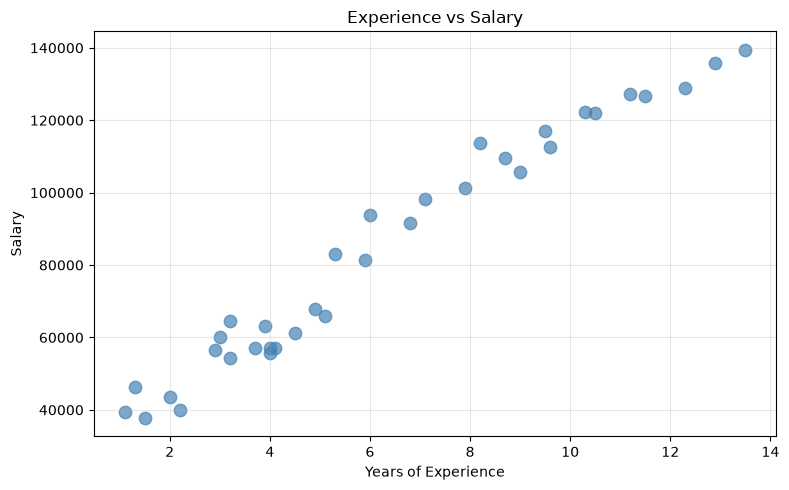

In [14]:
# Cell 3 — Visualise the data
plt.figure(figsize=(8, 5))
plt.scatter(df['YearsExperience'], df['Salary'], color='steelblue', alpha=0.7, s=80)
plt.xlabel('Years of Experience')
plt.ylabel('Salary')
plt.title('Experience vs Salary')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [19]:
# Cell 4 — Prepare data
X = df['YearsExperience'].values  # input
y = df['Salary'].values            # target

# Normalise X to help gradient descent converge faster
X_mean = X.mean()
X_std  = X.std()
X_norm = (X - X_mean) / X_std

print(f"X range: {X.min():.1f} to {X.max():.1f}")
print(f"y range: {y.min():.0f} to {y.max():.0f}")

X range: 1.1 to 13.5
y range: 37731 to 139465


In [20]:
# Cell 5 — Linear regression FROM SCRATCH (this is the core)
# Model: y_pred = w * x + b
# Cost:  MSE = (1/n) * sum((y_pred - y)^2)
# Goal:  find w and b that minimise cost

def compute_cost(X, y, w, b):
    n = len(X)
    predictions = w * X + b
    cost = (1 / (2 * n)) * np.sum((predictions - y) ** 2)
    return cost

def gradient_descent(X, y, w, b, learning_rate, epochs):
    n = len(X)
    cost_history = []

    for epoch in range(epochs):
        # Forward pass
        predictions = w * X + b

        # Compute gradients
        dw = (1 / n) * np.sum((predictions - y) * X)
        db = (1 / n) * np.sum(predictions - y)

        # Update weights
        w = w - learning_rate * dw
        b = b - learning_rate * db

        # Record cost every 100 epochs
        if epoch % 100 == 0:
            cost = compute_cost(X, y, w, b)
            cost_history.append(cost)

    return w, b, cost_history

# Initialise weights
w = 0.0
b = 0.0

# Train
learning_rate = 0.01
epochs = 3000

w, b, cost_history = gradient_descent(X_norm, y, w, b, learning_rate, epochs)

print(f"Trained weight (w): {w:.4f}")
print(f"Trained bias  (b):  {b:.4f}")
print(f"Final cost:         {cost_history[-1]:.2f}")

Trained weight (w): 31142.8227
Trained bias  (b):  83945.6000
Final cost:         17503384.10


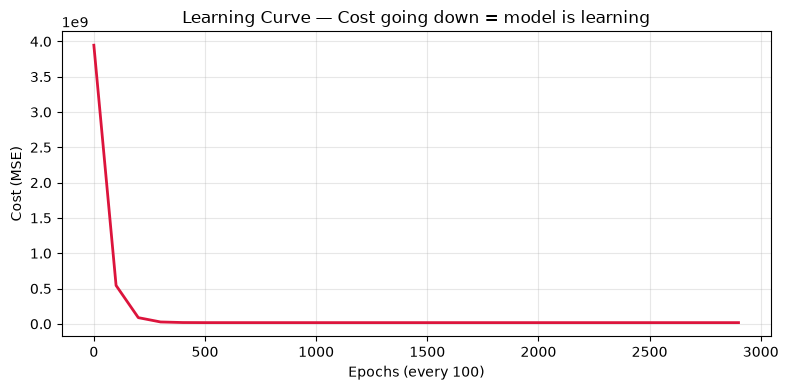

In [21]:
# Cell 6 — Plot learning curve
plt.figure(figsize=(8, 4))
plt.plot(range(0, epochs, 100), cost_history, color='crimson', linewidth=2)
plt.xlabel('Epochs (every 100)')
plt.ylabel('Cost (MSE)')
plt.title('Learning Curve — Cost going down = model is learning')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

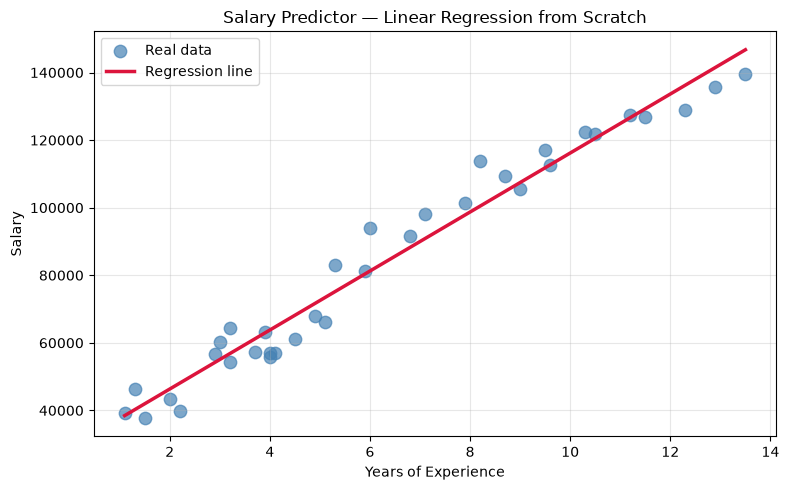

In [22]:
# Cell 7 — Plot regression line over data
X_line = np.linspace(X_norm.min(), X_norm.max(), 100)
y_line = w * X_line + b

# Convert back to original scale for x-axis labels
X_line_orig = X_line * X_std + X_mean

plt.figure(figsize=(8, 5))
plt.scatter(X, y, color='steelblue', alpha=0.7, s=80, label='Real data')
plt.plot(X_line_orig, y_line, color='crimson', linewidth=2.5, label='Regression line')
plt.xlabel('Years of Experience')
plt.ylabel('Salary')
plt.title('Salary Predictor — Linear Regression from Scratch')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [25]:
# Cell 8 — Make a prediction
def predict(years, w, b, X_mean, X_std):
    years_norm = (years - X_mean) / X_std
    salary = w * years_norm + b
    return salary

# Test it
for years in [1, 3, 5, 8, 10]:
    salary = predict(years, w, b, X_mean, X_std)
    print(f"{years} years experience → ${salary:,.0f}")

1 years experience → $37,591
3 years experience → $55,055
5 years experience → $72,519
8 years experience → $98,715
10 years experience → $116,179


In [24]:
# Cell 9 — Save model params (we'll use these in Streamlit)
np.save('model_params.npy', np.array([w, b, X_mean, X_std]))
print("Model saved to model_params.npy")

Model saved to model_params.npy
